In [1]:
import pandas as pd

df = pd.read_csv('../data/ai4i2020.csv')
df.sample(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
2267,2268,L49447,L,299.2,308.5,1370,52.4,61,0,0,0,0,0,0
520,521,L47700,L,297.6,309.5,1617,36.2,42,0,0,0,0,0,0
4942,4943,L52122,L,303.5,312.6,1602,34.2,108,0,0,0,0,0,0
8013,8014,M22873,M,300.9,312.0,1402,50.7,185,0,0,0,0,0,0
3428,3429,L50608,L,301.6,310.6,1391,49.4,164,0,0,0,0,0,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
df['TWF'].nunique()

2

In [6]:
failure_type = df.columns[9:].to_list()
for i in failure_type:
    k = (df[i].value_counts())
    print(k)


TWF
0    9954
1      46
Name: count, dtype: int64
HDF
0    9885
1     115
Name: count, dtype: int64
PWF
0    9905
1      95
Name: count, dtype: int64
OSF
0    9902
1      98
Name: count, dtype: int64
RNF
0    9981
1      19
Name: count, dtype: int64


In [7]:
#Failure Mode Frequencies
mfr = pd.Series({'Machine failure':df['Machine failure'].sum()*100/df['Machine failure'].count()})
for i in failure_type:
    fr = df[failure_type].sum()*100/df[failure_type].count()
fr = pd.concat([fr,mfr])
print(fr)

TWF                0.46
HDF                1.15
PWF                0.95
OSF                0.98
RNF                0.19
Machine failure    3.39
dtype: float64


In [8]:
#Can Multiple Failures occur together if yes how many times?
multi_failure = df[failure_type]
df['multi_failure'] = multi_failure.sum(axis = 1)
df[df['multi_failure']>1]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,multi_failure
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0,2
1324,1325,M16184,M,298.8,310.1,1243,74.5,194,1,0,0,1,1,0,2
1496,1497,L48676,L,298.0,308.7,1268,69.4,189,1,0,0,1,1,0,2
3611,3612,L50791,L,301.7,310.9,1405,46.4,207,1,1,0,0,0,1,2
3854,3855,L51034,L,302.4,311.0,1338,67.6,194,1,0,0,1,1,0,2
3943,3944,L51123,L,302.3,311.4,1333,66.7,205,1,0,0,1,1,0,2
4254,4255,L51434,L,302.6,311.0,1284,68.0,114,1,0,1,1,0,0,2
4342,4343,M19202,M,301.7,309.8,1284,68.2,111,1,0,1,1,0,0,2
4370,4371,L51550,L,302.0,309.9,1308,57.6,197,1,0,1,0,1,0,2
4383,4384,L51563,L,301.7,309.5,1298,65.5,229,1,0,1,0,1,0,2


In [9]:
# Number of failures by product quality type

product_quality = df['Type'].unique()

for failure in failure_type:
    print(f"\n{failure}")
    
    for quality in product_quality:
        count = df[(df['Type'] == quality) & (df[failure] == 1)].shape[0]
        print(f"{quality}: {count}")


TWF
M: 14
L: 25
H: 7

HDF
M: 31
L: 76
H: 8

PWF
M: 31
L: 59
H: 5

OSF
M: 9
L: 87
H: 2

RNF
M: 2
L: 13
H: 4


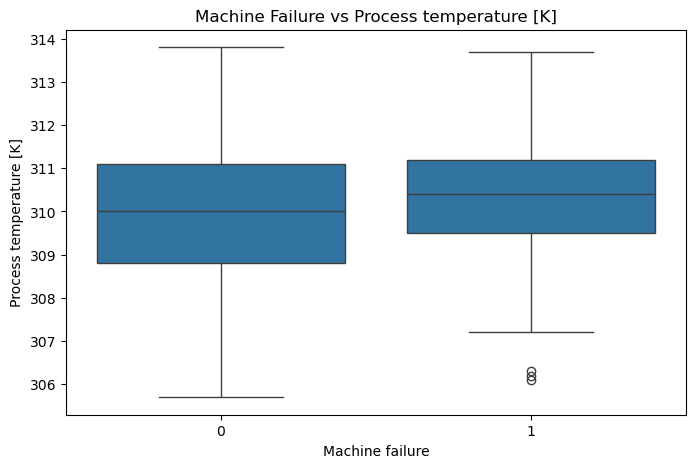

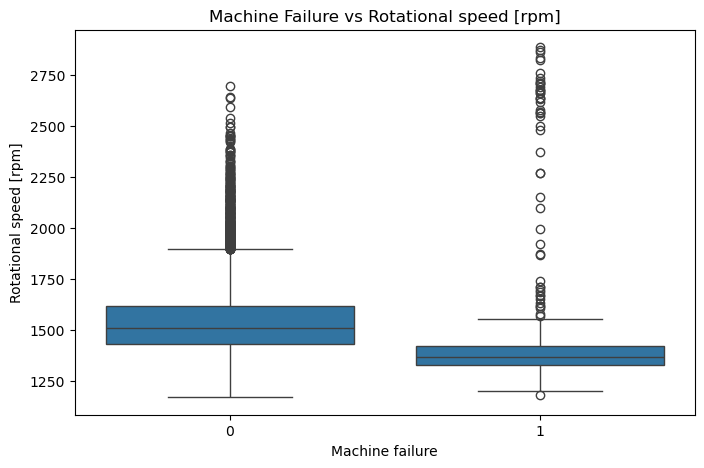

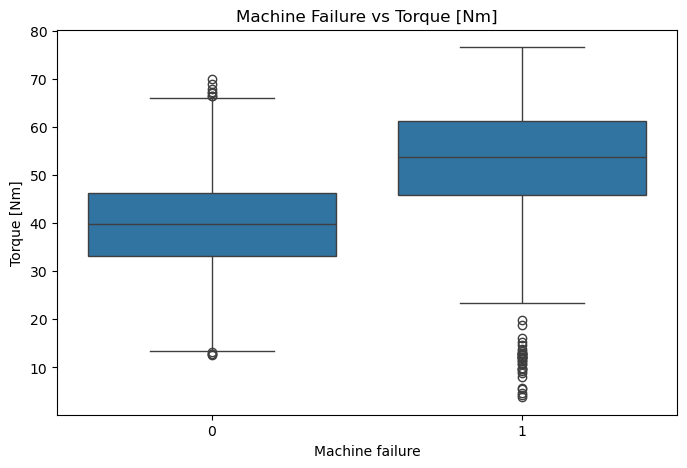

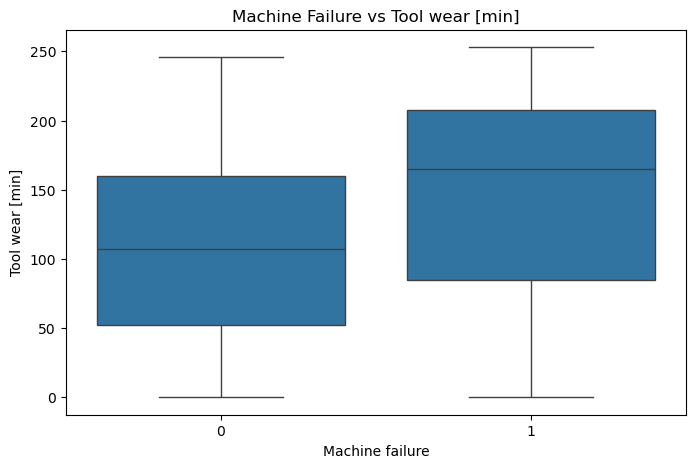

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sensor_cols = df.columns[4:8].to_list()
for col in sensor_cols:
    plt.figure(figsize=(8,5))
    
    sns.boxplot(
        x='Machine failure',
        y=col,
        data=df
    )
    
    plt.title(f'Machine Failure vs {col}')
    plt.show()

<Axes: xlabel='Torque [Nm]', ylabel='Tool wear [min]'>

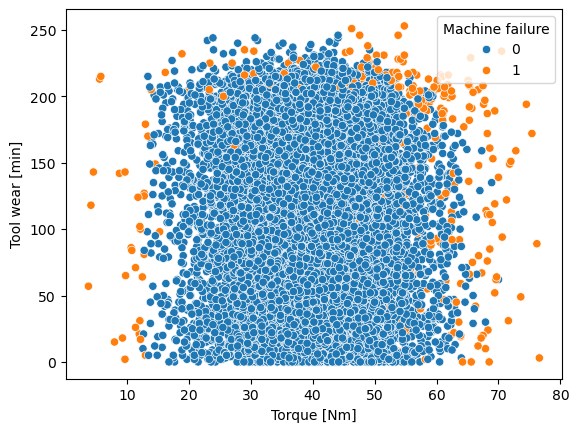

In [16]:
# Relationship Analysis
sns.scatterplot(x = df[sensor_cols[2]], y = df[sensor_cols[3]],hue = df['Machine failure'])

<Axes: xlabel='Torque [Nm]', ylabel='Rotational speed [rpm]'>

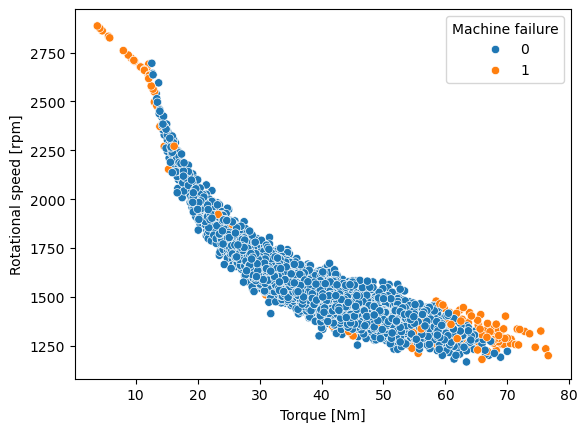

In [18]:
sns.scatterplot(x = df[sensor_cols[2]], y = df[sensor_cols[1]],hue = df['Machine failure'])

In [44]:
df['temp_diff'] = df[df.columns[4]] - df[df.columns[3]]

df['estimated_power'] = df[df.columns[5]]*df[df.columns[6]]*2*3.14/60
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,multi_failure,temp_diff,estimated_power
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,10.5,6948.066400
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0,10.5,6823.261867
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0,10.4,7745.458933
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0,10.4,5924.499667
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0,10.5,5894.826667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,0,9.6,4952.617333
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,0,9.5,5431.948800
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,0,9.6,5750.700667
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,0,9.7,7147.477333


<Axes: xlabel='Machine failure', ylabel='temp_diff'>

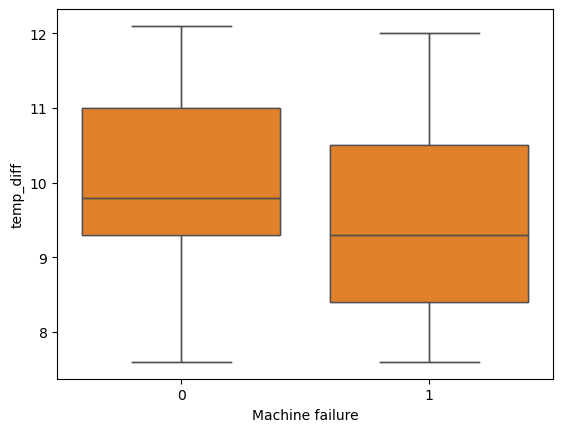

In [45]:
# Temperature Difference vs Machine Failure
sns.boxplot(x = 'Machine failure',y = 'temp_diff', data = df)


<Axes: xlabel='Machine failure', ylabel='estimated_power'>

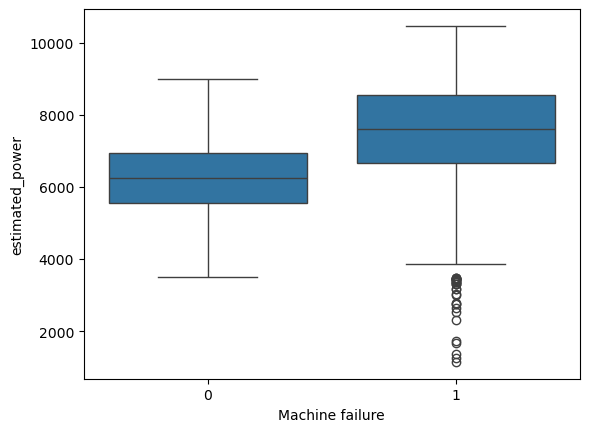

In [47]:
#Power vs machine Failure
sns.boxplot(x = 'Machine failure',y = 'estimated_power', data = df)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
 14  multi_failure          

In [50]:
keep_cols = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'temp_diff',
    'estimated_power',
    'Machine failure'
]

df = df[keep_cols]

df.sample(5)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff,estimated_power,Machine failure
4558,L,302.7,310.7,1369,47.5,11,8.0,6806.211667,1
7905,M,300.8,312.4,1465,43.7,139,11.6,6700.812333,0
1509,L,298.0,308.5,1429,37.7,220,10.5,5638.738733,1
8455,L,298.6,309.9,1356,59.5,34,11.3,8444.716000,0
9785,H,298.7,309.7,1697,29.8,74,11.0,5293.056133,0
